<a href="https://colab.research.google.com/github/yatori17/obesity-level/blob/main/Obesity_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook for Obesity Report

In [70]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib
from google.colab import files

print(f"NumPy: {np.__version__}")
print(f"Sklearn: {sklearn.__version__}")

NumPy: 2.0.2
Sklearn: 1.6.1


## Carga de dados do Dataset

In [71]:
url = "https://raw.githubusercontent.com/yatori17/burnout/refs/heads/main/ObesityDataSet_raw_and_data_sinthetic.csv"

dataset = pd.read_csv(url, delimiter=',')

dataset.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Separação em conjunto de treino e conjunto de teste (Holdout)


In [72]:
test_size = 0.20
seed = 7
array = dataset.values
X = dataset.drop(["NObeyesdad"], axis = 1)
X = pd.get_dummies(X, drop_first=True)
y = dataset["NObeyesdad"]

# Separação em treino (80%) e teste (20%) com estratificação para manter o equilíbrio das classes de obesidade.
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y)
print(X)
print(y)

scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

            Age    Height      Weight  FCVC  NCP      CH2O       FAF  \
0     21.000000  1.620000   64.000000   2.0  3.0  2.000000  0.000000   
1     21.000000  1.520000   56.000000   3.0  3.0  3.000000  3.000000   
2     23.000000  1.800000   77.000000   2.0  3.0  2.000000  2.000000   
3     27.000000  1.800000   87.000000   3.0  3.0  2.000000  2.000000   
4     22.000000  1.780000   89.800000   2.0  1.0  2.000000  0.000000   
...         ...       ...         ...   ...  ...       ...       ...   
2106  20.976842  1.710730  131.408528   3.0  3.0  1.728139  1.676269   
2107  21.982942  1.748584  133.742943   3.0  3.0  2.005130  1.341390   
2108  22.524036  1.752206  133.689352   3.0  3.0  2.054193  1.414209   
2109  24.361936  1.739450  133.346641   3.0  3.0  2.852339  1.139107   
2110  23.664709  1.738836  133.472641   3.0  3.0  2.863513  1.026452   

           TUE  Gender_Male  family_history_with_overweight_yes  ...  CAEC_no  \
0     1.000000        False                           

## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

KNN: 0.871450 (0.013476)
CART: 0.924785 (0.021448)
NB: 0.520752 (0.024961)
SVM: 0.563433 (0.048436)


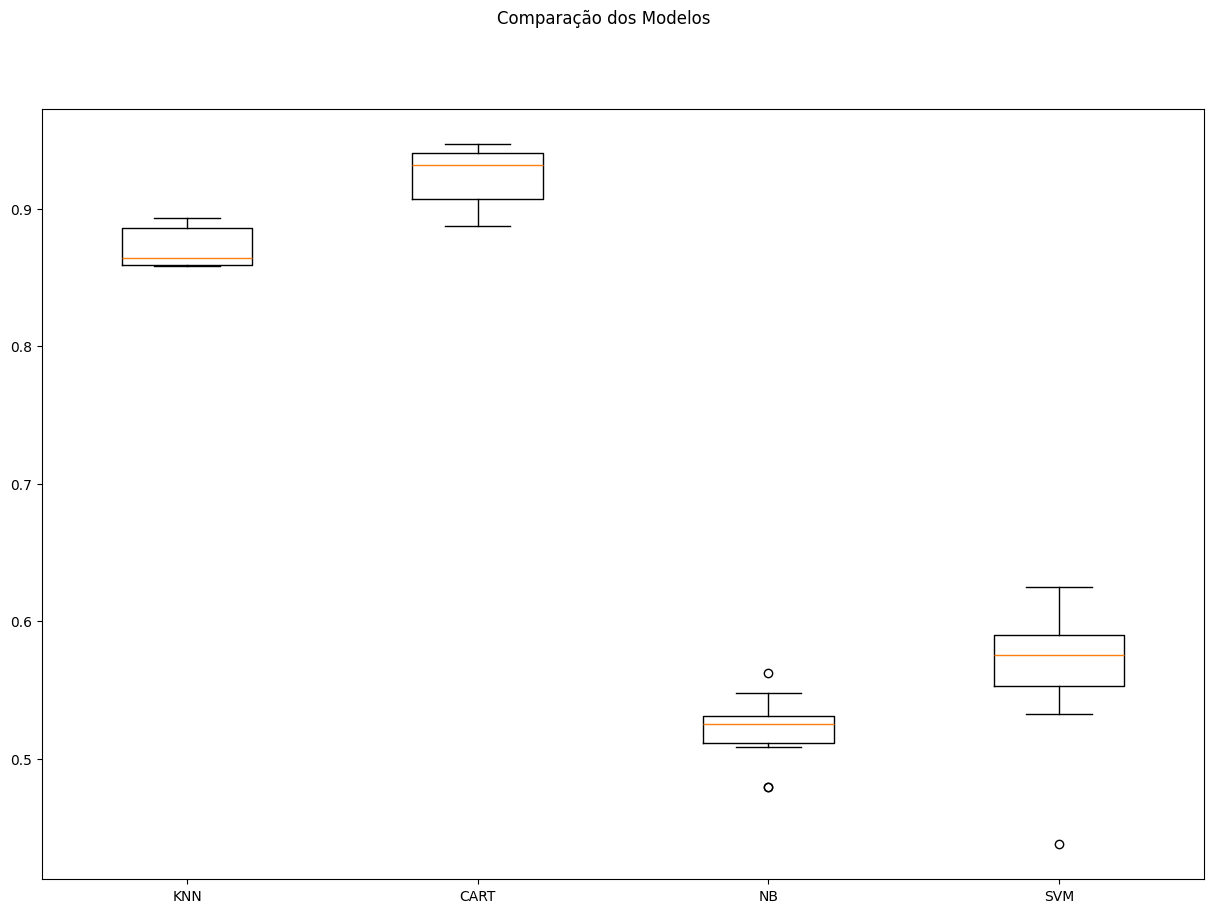

In [73]:
np.random.seed(7)

models = []

models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

### Criação e avaliação de modelos: dados padronizados e normalizados

KNN-orig: 0.871 (0.013)
CART-orig: 0.930 (0.018)
NB-orig: 0.521 (0.025)
SVM-orig: 0.563 (0.048)
KNN-padr: 0.794 (0.027)
CART-padr: 0.926 (0.016)
NB-padr: 0.487 (0.019)
SVM-padr: 0.858 (0.029)
KNN-norm: 0.767 (0.035)
CART-norm: 0.927 (0.022)
NB-norm: 0.492 (0.023)
SVM-norm: 0.768 (0.033)


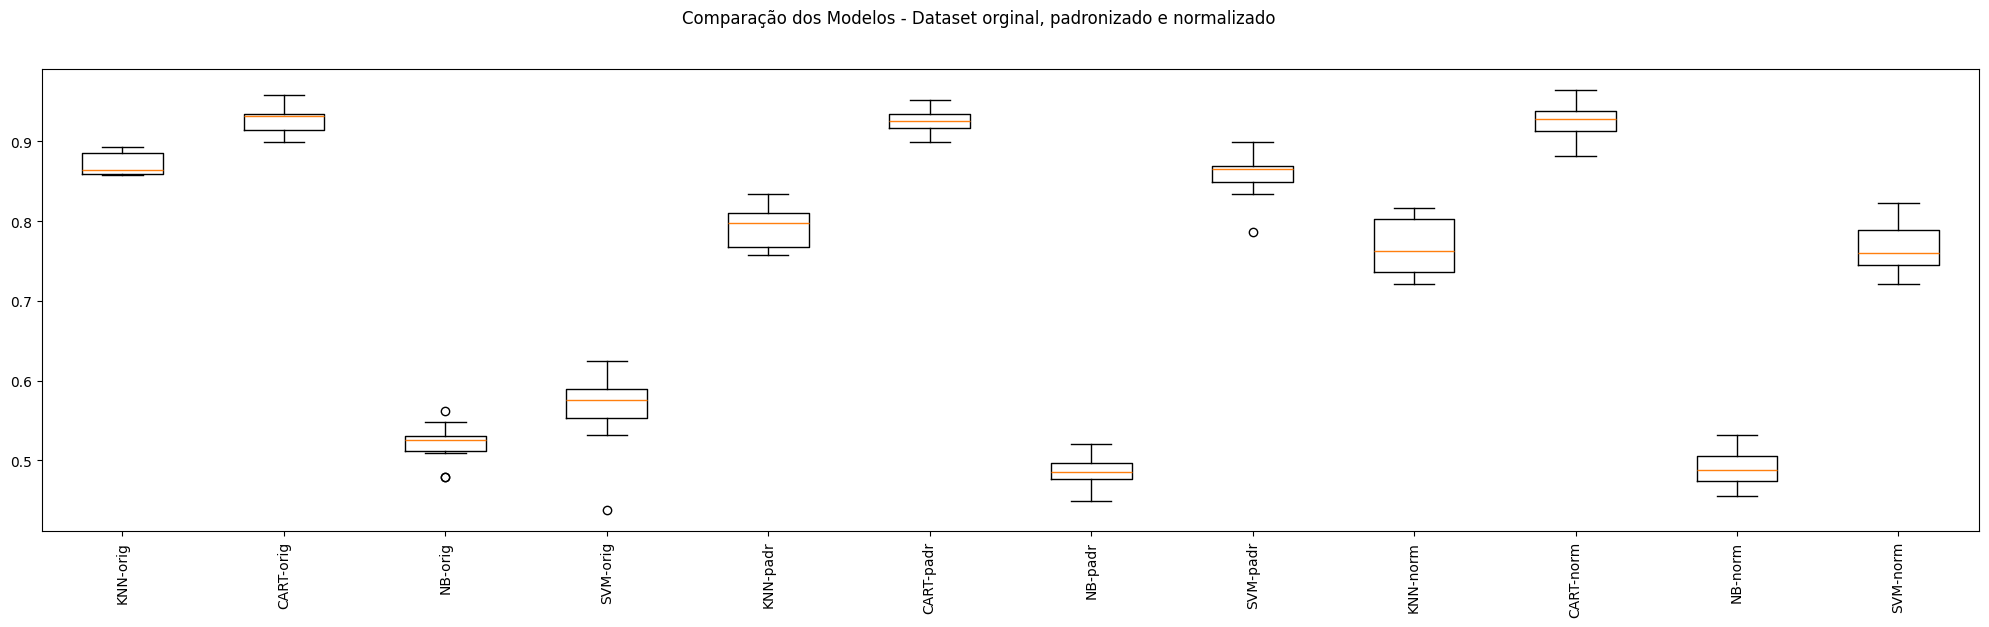

In [74]:
pipelines = []
results = []
names = []


# Algoritmos que serão utilizados:  KNN, Árvore de Classificação, Naive Bayes e SVM
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))

pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

### Otimização dos hiperparâmetros

In [75]:
# Otimizacao do melhor modelo que foi a Árvore de classificação
cart = ('CART', DecisionTreeClassifier(random_state=7))
standard_scaler = ('StandardScaler', StandardScaler())

pipeline = Pipeline(steps=[standard_scaler, cart])

param_grid = {
    'CART__max_depth': [3, 5, 7, 10, None],
    'CART__min_samples_split': [2, 5, 10],
    'CART__criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=kfold #Cross validation
)

grid.fit(X_train, y_train)

print("Melhor score:", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Melhor score: 0.9508417864187095
Melhores parâmetros: {'CART__criterion': 'entropy', 'CART__max_depth': 10, 'CART__min_samples_split': 2}


Após a comparação de diferentes algoritmos (KNN, SVM, Naive Bayes e Árvore de Decisão) em diferentes estados do dataset, o algoritmo CART (Decision Tree) apresentou o melhor equilíbrio entre acurácia e estabilidade (menor desvio padrão). Por isso, ele foi selecionado para a otimização de hiperparâmetros e exportação final.\

## Finalização do Modelo

In [76]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('CART', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=10,
        min_samples_split=2,
        random_state=7
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

0.9361702127659575
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.94        54
      Normal_Weight       0.91      0.86      0.88        58
     Obesity_Type_I       0.93      0.96      0.94        70
    Obesity_Type_II       0.95      0.92      0.93        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.90      0.90      0.90        58
Overweight_Level_II       0.93      0.97      0.95        58

           accuracy                           0.94       423
          macro avg       0.94      0.93      0.93       423
       weighted avg       0.94      0.94      0.94       423



Preparação do Modelo com todos os dados do dataset

In [77]:
# Preparação do modelo com todos os dados do dataset para que tenha uma melhor acurácia
model.fit(X, y)
# Testando com a primeira linha do próprio dataset
teste_predicao = model.predict(X.iloc[[0]])
print(f"Predição para a primeira linha: {teste_predicao}")

Predição para a primeira linha: ['Normal_Weight']


## Simulando a aplicação do modelo em dados não vistos

In [78]:
def preparar_entrada_obesidade(raw_data, model_features):
    entrada = pd.DataFrame(raw_data)

    entrada = pd.get_dummies(entrada, drop_first=True)

    # Garantir todas as colunas do treino
    for col in model_features:
        if col not in entrada.columns:
            entrada[col] = 0

    # Garantir mesma ordem
    entrada = entrada[model_features]

    return entrada

new_raw_data = {
    'Gender': ['Male', 'Female', 'Male'],
    'Age': [25, 40, 32],
    'Height': [1.75, 1.68, 1.80],
    'Weight': [70, 95, 120],
    'family_history_with_overweight': ['yes', 'yes', 'yes'],
    'FAVC': ['yes', 'yes', 'yes'],
    'FCVC': [3, 2, 1],
    'NCP': [3, 4, 4],
    'CAEC': ['Sometimes', 'Sometimes', 'Sometimes'],
    'SMOKE': ['no', 'no', 'no'],
    'CH2O': [2, 1, 1],
    'SCC': ['no', 'no', 'no'],
    'FAF': [3, 1, 0],
    'TUE': [1, 3, 5],
    'CALC': ['Sometimes', 'Sometimes', 'Sometimes'],
    'MTRANS': ['Public_Transportation'] * 3
}

entrada_final = preparar_entrada_obesidade(new_raw_data, X.columns)

predicoes = model.predict(entrada_final)

print(predicoes)

['Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II']


In [79]:
saidas = model.predict(X_test)
comparacao = pd.DataFrame({
    "Real": y_test.values[:10],
    "Predito": saidas[:10]
})

print(comparacao)

                  Real              Predito
0      Obesity_Type_II      Obesity_Type_II
1  Overweight_Level_II  Overweight_Level_II
2        Normal_Weight        Normal_Weight
3       Obesity_Type_I       Obesity_Type_I
4       Obesity_Type_I       Obesity_Type_I
5  Insufficient_Weight  Insufficient_Weight
6       Obesity_Type_I       Obesity_Type_I
7      Obesity_Type_II      Obesity_Type_II
8        Normal_Weight        Normal_Weight
9     Obesity_Type_III     Obesity_Type_III


Exportar Pipeline

In [80]:
# Exportar pipeline para que seja usado na aplicação full stack

joblib.dump(model, "obesity_model.pkl", protocol=4)
files.download("obesity_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>